In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
df = pd.read_csv('/content/hajj_umrah_crowd_management_dataset.csv')

In [ ]:
df.head()

,Timestamp,Location_Lat,Location_Long,Crowd_Density,Movement_Speed,Activity_Type,Weather_Conditions,Temperature,Sound_Level_dB,AR_System_Interaction,...,Incident_Type,Crowd_Morale,Pilgrim_Experience,Interaction_Frequency,Distance_Between_People_m,Event_Type,Time_Spent_at_Location_minutes,AR_Navigation_Success,Satisfaction_Rating,Perceived_Safety_Rating
0,2/28/2024 5:36,21.258846,39.983949,High,0.90,Tawaf,Clear,44,82,Started,...,Theft,Neutral,Experienced,6,0.94,Transport Delay,77,No,2,3
1,7/15/2024 4:07,21.353403,39.850382,Low,0.55,Resting,Clear,39,80,Completed,...,Security Breach,Negative,First-Time,8,2.04,Religious Activity,92,No,2,3
2,6/6/2024 8:27,21.252375,39.937753,Medium,0.94,Prayer,Clear,32,84,Started,...,Unruly Behavior,Negative,Experienced,2,1.85,Crowd Congestion,16,Yes,5,4
3,12/23/2024 6:29,21.377740,39.813333,Medium,0.55,Prayer,Clear,41,79,Started,...,Unruly Behavior,Negative,Experienced,2,0.96,Transport Delay,74,No,3,3
4,8/19/2024 18:00,21.360457,39.950974,High,0.36,Sa’i,Rainy,44,67,Completed,...,Theft,Negative,First-Time,10,1.05,Transport Delay,20,No,3,1


**Understanding data formats**

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10000
Number of columns: 30


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Timestamp                       10000 non-null  object 
 1   Location_Lat                    10000 non-null  float64
 2   Location_Long                   10000 non-null  float64
 3   Crowd_Density                   10000 non-null  object 
 4   Movement_Speed                  10000 non-null  float64
 5   Activity_Type                   10000 non-null  object 
 6   Weather_Conditions              10000 non-null  object 
 7   Temperature                     10000 non-null  int64  
 8   Sound_Level_dB                  10000 non-null  int64  
 9   AR_System_Interaction           10000 non-null  object 
 10  Fatigue_Level                   10000 non-null  object 
 11  Stress_Level                    10000 non-null  object 
 12  Queue_Time_minutes              1

In [ ]:
df.describe()

,Location_Lat,Location_Long,Movement_Speed,Temperature,Sound_Level_dB,Queue_Time_minutes,Waiting_Time_for_Transport,Security_Checkpoint_Wait_Time,Interaction_Frequency,Distance_Between_People_m,Time_Spent_at_Location_minutes,Satisfaction_Rating,Perceived_Safety_Rating
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,21.299628,39.898729,0.845493,37.515400,74.914200,30.256500,59.661500,17.578400,4.969700,1.497744,65.018600,3.010100,2.986800
std,0.057664,0.057236,0.377836,4.610736,9.007439,17.681492,35.093146,7.529829,3.167015,0.570497,32.039608,1.425623,1.416554
min,21.200078,39.800043,0.200000,30.000000,60.000000,0.000000,0.000000,5.000000,0.000000,0.500000,10.000000,1.000000,1.000000
25%,21.249454,39.849039,0.520000,33.000000,67.000000,15.000000,29.000000,11.000000,2.000000,1.010000,37.000000,2.000000,2.000000
50%,21.299998,39.899346,0.840000,38.000000,75.000000,30.000000,59.000000,18.000000,5.000000,1.490000,65.000000,3.000000,3.000000
75%,21.349764,39.947166,1.170000,42.000000,83.000000,46.000000,90.000000,24.000000,8.000000,1.990000,93.000000,4.000000,4.000000
max,21.399917,39.999994,1.500000,45.000000,90.000000,60.000000,120.000000,30.000000,10.000000,2.500000,120.000000,5.000000,5.000000


In [ ]:
df.describe(include="object")

,Timestamp,Crowd_Density,Activity_Type,Weather_Conditions,AR_System_Interaction,Fatigue_Level,Stress_Level,Health_Condition,Age_Group,Nationality,Transport_Mode,Emergency_Event,Incident_Type,Crowd_Morale,Pilgrim_Experience,Event_Type,AR_Navigation_Success
count,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000
unique,9900,3,5,3,3,3,3,5,4,6,4,2,5,3,2,4,2
top,10/21/2024 2:02,Medium,Walking,Clear,Started,Low,Medium,Heatstroke,31-50,Other,Walking,No,Theft,Positive,Experienced,Religious Activity,Yes
freq,2,3381,2017,3413,3404,3354,3370,2075,2549,1743,2553,5006,2049,3384,5039,2531,5005


In [ ]:
cols = ['Health_Condition', 'Fatigue_Level',
        'Age_Group', 'Crowd_Density', 'Stress_Level']

for col in cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Health_Condition:
Health_Condition
Heatstroke     2075
Injured        2029
Normal         1997
Dehydration    1968
Fainting       1931
Name: count, dtype: int64

Fatigue_Level:
Fatigue_Level
Low       3354
High      3330
Medium    3316
Name: count, dtype: int64

Age_Group:
Age_Group
31-50    2549
70+      2520
18-30    2478
51-70    2453
Name: count, dtype: int64

Crowd_Density:
Crowd_Density
Medium    3381
High      3325
Low       3294
Name: count, dtype: int64

Stress_Level:
Stress_Level
Medium    3370
High      3327
Low       3303
Name: count, dtype: int64


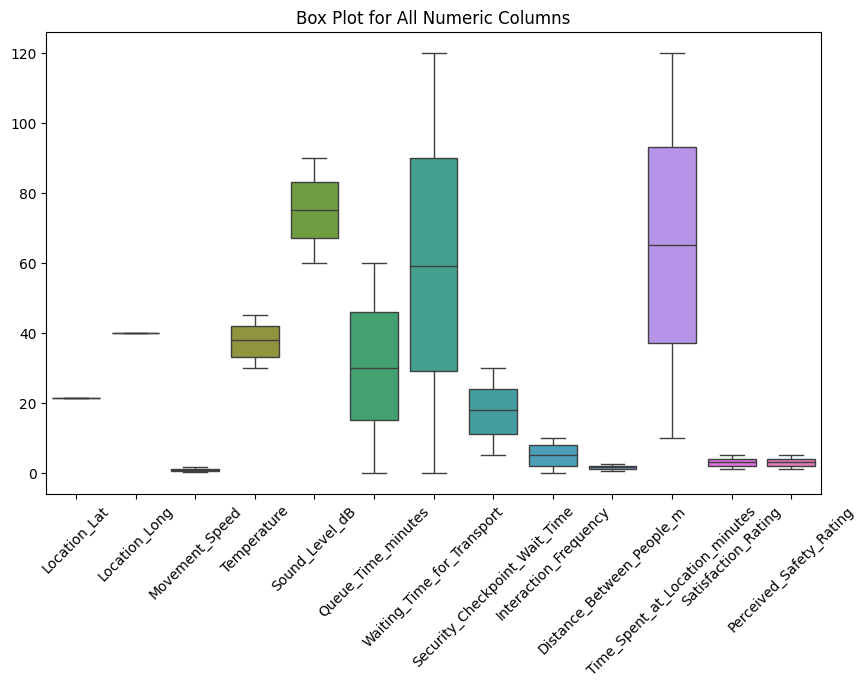

In [ ]:
#Boxplot for check Outliers
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10,6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=45)
plt.title("Box Plot for All Numeric Columns")
plt.show()

**There are no outlier values**

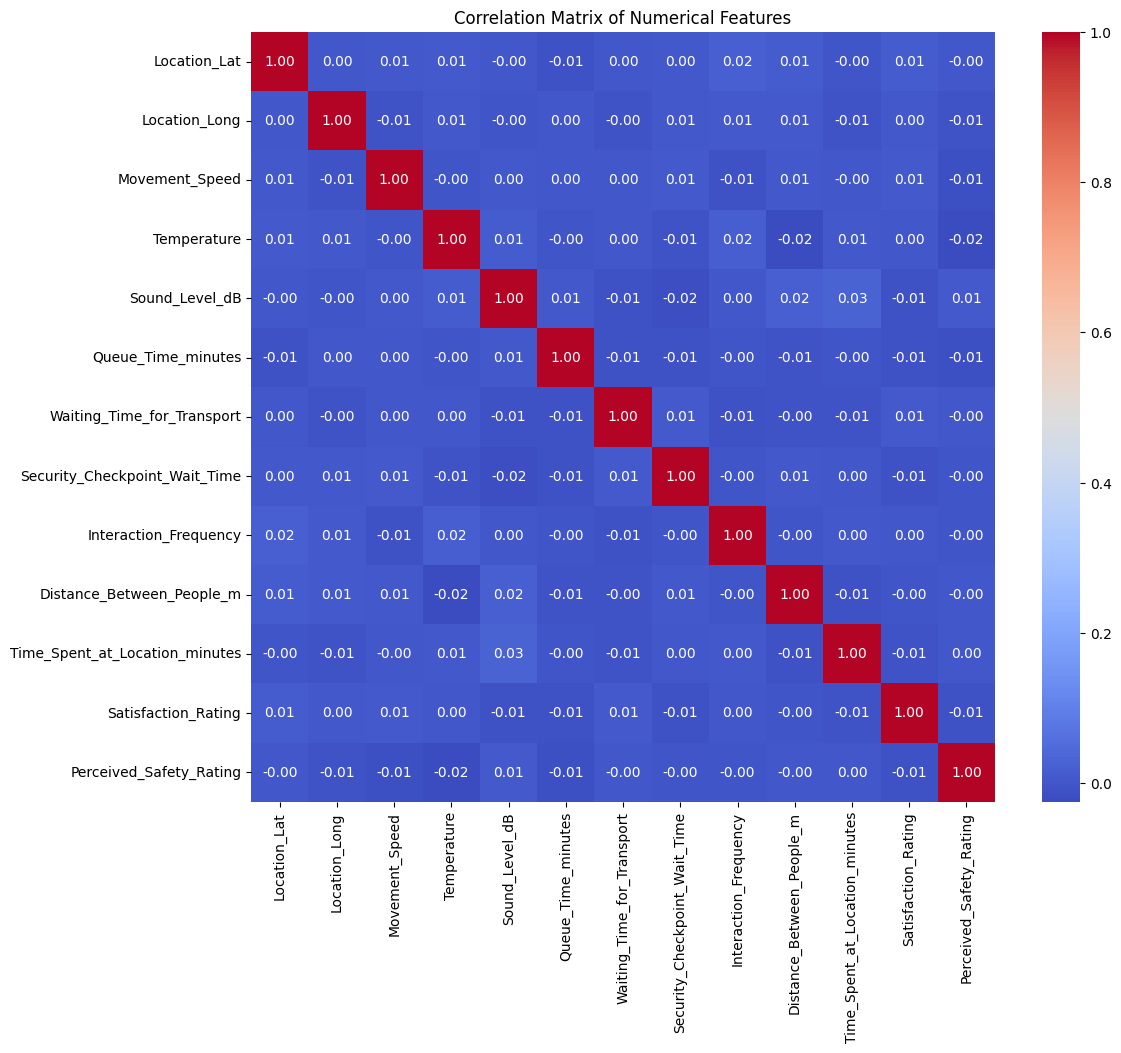

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# **Preprocessing and Cleaning**

**Take a copy of the original data**

In [ ]:
clean_df = df.copy()

In [ ]:
#Check column names
df.columns.tolist()

['Timestamp',
 'Location_Lat',
 'Location_Long',
 'Crowd_Density',
 'Movement_Speed',
 'Activity_Type',
 'Weather_Conditions',
 'Temperature',
 'Sound_Level_dB',
 'AR_System_Interaction',
 'Fatigue_Level',
 'Stress_Level',
 'Queue_Time_minutes',
 'Health_Condition',
 'Age_Group',
 'Nationality',
 'Transport_Mode',
 'Waiting_Time_for_Transport',
 'Security_Checkpoint_Wait_Time',
 'Emergency_Event',
 'Incident_Type',
 'Crowd_Morale',
 'Pilgrim_Experience',
 'Interaction_Frequency',
 'Distance_Between_People_m',
 'Event_Type',
 'Time_Spent_at_Location_minutes',
 'AR_Navigation_Success',
 'Satisfaction_Rating',
 'Perceived_Safety_Rating']

In [ ]:
#Cleaning column names
clean_df.columns = (
    clean_df.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
    .str.replace(r"[^a-zA-Z0-9_\u0600-\u06FF]", "", regex=True)
)

clean_df.columns.tolist()

['timestamp',
 'location_lat',
 'location_long',
 'crowd_density',
 'movement_speed',
 'activity_type',
 'weather_conditions',
 'temperature',
 'sound_level_db',
 'ar_system_interaction',
 'fatigue_level',
 'stress_level',
 'queue_time_minutes',
 'health_condition',
 'age_group',
 'nationality',
 'transport_mode',
 'waiting_time_for_transport',
 'security_checkpoint_wait_time',
 'emergency_event',
 'incident_type',
 'crowd_morale',
 'pilgrim_experience',
 'interaction_frequency',
 'distance_between_people_m',
 'event_type',
 'time_spent_at_location_minutes',
 'ar_navigation_success',
 'satisfaction_rating',
 'perceived_safety_rating']

In [ ]:
clean_df.isnull().sum()

,0
timestamp,0
location_lat,0
location_long,0
crowd_density,0
movement_speed,0
activity_type,0
weather_conditions,0
temperature,0
sound_level_db,0
ar_system_interaction,0


**No values ​​are missing**

In [ ]:
#duplicated
clean_df.duplicated().sum()

np.int64(0)

**No values ​​are duplicated**

In [ ]:
#Cleaning text from spaces
text_columns = clean_df.select_dtypes(include="object").columns

for col in text_columns:
    clean_df.loc[:, col] = clean_df[col].astype(str).str.strip()

clean_df.head()

,timestamp,location_lat,location_long,crowd_density,movement_speed,activity_type,weather_conditions,temperature,sound_level_db,ar_system_interaction,...,incident_type,crowd_morale,pilgrim_experience,interaction_frequency,distance_between_people_m,event_type,time_spent_at_location_minutes,ar_navigation_success,satisfaction_rating,perceived_safety_rating
0,2/28/2024 5:36,21.258846,39.983949,High,0.90,Tawaf,Clear,44,82,Started,...,Theft,Neutral,Experienced,6,0.94,Transport Delay,77,No,2,3
1,7/15/2024 4:07,21.353403,39.850382,Low,0.55,Resting,Clear,39,80,Completed,...,Security Breach,Negative,First-Time,8,2.04,Religious Activity,92,No,2,3
2,6/6/2024 8:27,21.252375,39.937753,Medium,0.94,Prayer,Clear,32,84,Started,...,Unruly Behavior,Negative,Experienced,2,1.85,Crowd Congestion,16,Yes,5,4
3,12/23/2024 6:29,21.377740,39.813333,Medium,0.55,Prayer,Clear,41,79,Started,...,Unruly Behavior,Negative,Experienced,2,0.96,Transport Delay,74,No,3,3
4,8/19/2024 18:00,21.360457,39.950974,High,0.36,Sa’i,Rainy,44,67,Completed,...,Theft,Negative,First-Time,10,1.05,Transport Delay,20,No,3,1


In [ ]:
#Checking the unique values ​​of the columns
cat_cols = ['crowd_density', 'activity_type', 'weather_conditions',
            'ar_system_interaction', 'fatigue_level', 'stress_level',
            'health_condition', 'age_group', 'nationality',
            'transport_mode', 'emergency_event', 'incident_type',
            'crowd_morale', 'pilgrim_experience', 'event_type',
            'ar_navigation_success']

for col in cat_cols:
    print(f"{col}: {clean_df[col].unique()}")

crowd_density: ['High' 'Low' 'Medium']
activity_type: ['Tawaf' 'Resting' 'Prayer' 'Sa’i' 'Walking']
weather_conditions: ['Clear' 'Rainy' 'Cloudy']
ar_system_interaction: ['Started' 'Completed' 'In Progress']
fatigue_level: ['Medium' 'High' 'Low']
stress_level: ['High' 'Medium' 'Low']
health_condition: ['Fainting' 'Injured' 'Heatstroke' 'Normal' 'Dehydration']
age_group: ['70+' '18-30' '51-70' '31-50']
nationality: ['Saudi' 'Pakistani' 'Egyptian' 'Indonesian' 'Indian' 'Other']
transport_mode: ['Car' 'Walking' 'Train' 'Bus']
emergency_event: ['Yes' 'No']
incident_type: ['Theft' 'Security Breach' 'Unruly Behavior' 'Lost Item'
 'Medical Emergency']
crowd_morale: ['Neutral' 'Negative' 'Positive']
pilgrim_experience: ['Experienced' 'First-Time']
event_type: ['Transport Delay' 'Religious Activity' 'Crowd Congestion'
 'Medical Emergency']
ar_navigation_success: ['No' 'Yes']


**All categorical columns contain unique values no need for Standardization**

In [ ]:
#Data Transformation
clean_df = df.copy()


clean_df['Age_Group'] = clean_df['Age_Group'].map({
    '18-30': 1, '31-50': 2, '51-70': 3, '70+': 4
})

clean_df['Crowd_Density'] = clean_df['Crowd_Density'].map({
    'Low': 1, 'Medium': 2, 'High': 3
})

clean_df['Fatigue_Level'] = clean_df['Fatigue_Level'].map({
    'Low': 1, 'Medium': 2, 'High': 3
})

clean_df['Stress_Level'] = clean_df['Stress_Level'].map({
    'Low': 1, 'Medium': 2, 'High': 3
})

clean_df['Health_Condition'] = clean_df['Health_Condition'].map({
    'Fainting': 1, 'Injured': 2, 'Heatstroke': 3, 'Normal': 4, 'Dehydration': 5
})

# Target
clean_df['Emergency_Event'] = clean_df['Emergency_Event'].map({
    'Yes': 1, 'No': 0
})
print(clean_df['Age_Group'].unique())
print(clean_df['Crowd_Density'].unique())
print(clean_df['Fatigue_Level'].unique())
print(clean_df['Stress_Level'].unique())
print(clean_df['Emergency_Event'].unique())

[4 1 3 2]
[3 1 2]
[2 3 1]
[3 2 1]
[1 0]


In [ ]:
#Final chech of data quality
print("Missing values after cleaning:", clean_df.isnull().sum().sum())
print("Duplicated rows after cleaning:", clean_df.duplicated().sum())
print("Final rows:", clean_df.shape[0])
print("Final columns:", clean_df.shape[1])

Missing values after cleaning: 0
Duplicated rows after cleaning: 0
Final rows: 10000
Final columns: 30


In [ ]:
#Summary befor and after cleaning
summary = pd.DataFrame({
    "Metric": [
        "Number of rows",
        "Number of columns",
        "Missing values",
        "Duplicated rows"
    ],
    "Before Cleaning": [
        df.shape[0],
        df.shape[1],
        int(df.isnull().sum().sum()),
        int(df.duplicated().sum())
    ],
    "After Cleaning": [
        clean_df.shape[0],
        clean_df.shape[1],
        int(clean_df.isnull().sum().sum()),
        int(clean_df.duplicated().sum())
    ]
})

summary

,Metric,Before Cleaning,After Cleaning
0,Number of rows,10000,10000
1,Number of columns,30,30
2,Missing values,0,0
3,Duplicated rows,0,0


# **Data Analysis**

In [ ]:
clean_df['Combined_Risk'] = (
    clean_df['Temperature'] * clean_df['Fatigue_Level']
)

In [ ]:
#Featuer 1
clean_df['Risk_Level'] = pd.qcut(
    clean_df['Combined_Risk'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

In [ ]:
mapping = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}

clean_df['Risk_Level'] = clean_df['Risk_Level'].map(mapping).astype(int)

In [ ]:
#Featuer 2
clean_df['Heat_Risk'] = clean_df['Temperature'] * clean_df['Age_Group']

In [ ]:
#Featuer 3
clean_df['Crowd_Pressure'] = (
    clean_df['Crowd_Density'] /
    (clean_df['Distance_Between_People_m'] + 1)
)

In [ ]:
features = [
    'Crowd_Density', 'Temperature', 'Fatigue_Level', 'Stress_Level',
    'Health_Condition', 'Age_Group', 'Movement_Speed', 'Queue_Time_minutes',
    'Distance_Between_People_m', 'Combined_Risk', 'Risk_Level', 'Heat_Risk',
    'Crowd_Pressure'
]
X = clean_df[features]
y = clean_df['Emergency_Event']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

In [ ]:
#Model 1
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)


dt_model.fit(X_train, y_train)


dt_train_predictions = dt_model.predict(X_train)
dt_predictions = dt_model.predict(X_test)

In [ ]:
#Model 2
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

rf_model.fit(X_train, y_train)

rf_train_predictions = rf_model.predict(X_train)
rf_predictions = rf_model.predict(X_test)

In [ ]:
#Model 3
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss')

xgb_model.fit(X_train, y_train)

xgb_train_predictions = xgb_model.predict(X_train)
xgb_predictions = xgb_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:10:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# Decision Tree
print("Decision Tree:")
print("Train Accuracy:", accuracy_score(y_train, dt_train_predictions)*100)
print("Test Accuracy :", accuracy_score(y_test, dt_predictions)*100)
print("-"*30)

# Random Forest
print("Random Forest:")
print("Train Accuracy:", accuracy_score(y_train, rf_train_predictions)*100)
print("Test Accuracy :", accuracy_score(y_test, rf_predictions)*100)
print("-"*30)

# XGBoost
print("XGBoost:")
print("Train Accuracy:", accuracy_score(y_train, xgb_train_predictions)*100)
print("Test Accuracy :", accuracy_score(y_test, xgb_predictions)*100)

Decision Tree:
Train Accuracy: 51.949999999999996
Test Accuracy : 52.2
------------------------------
Random Forest:
Train Accuracy: 64.1125
Test Accuracy : 50.5
------------------------------
XGBoost:
Train Accuracy: 75.375
Test Accuracy : 48.5


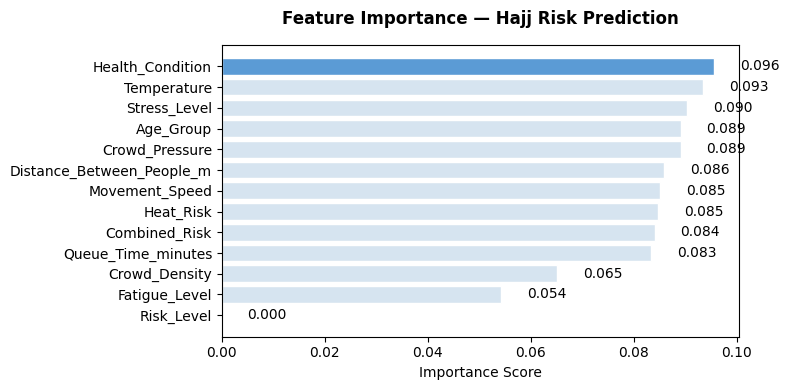


Top feature: Health_Condition (0.096)


In [ ]:
# Which features matter most?
importance = pd.Series(xgb_model.feature_importances_, index=X.columns)
importance_sorted = importance.sort_values()

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(
    importance_sorted.index,
    importance_sorted.values,
    color=[
        '#5B9BD5' if v == importance_sorted.max() else '#D6E4F0'
        for v in importance_sorted.values
    ],
    edgecolor='white'
)

ax.set_title('Feature Importance — Hajj Risk Prediction',
             fontweight='bold', pad=15)

ax.set_xlabel('Importance Score')

# values on bars
for bar, val in zip(bars, importance_sorted.values):
    ax.text(val + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}',
            va='center',
            fontsize=10)

plt.tight_layout()
plt.show()

# top feature
print("\nTop feature:", importance.idxmax(), f"({importance.max():.3f})")

In [ ]:
# Define new pilgrims
new_pilgrims = pd.DataFrame({
    'Crowd_Density'             : [3,        1       ],
    'Temperature'               : [45.0,     32.0    ],
    'Fatigue_Level'             : [3,        1       ],
    'Stress_Level'              : [3,        1       ],
    'Health_Condition'          : [1,        3       ],
    'Age_Group'                 : [4,        1       ],
    'Movement_Speed'            : [0.5,      3.0     ],
    'Queue_Time_minutes'        : [90.0,     10.0    ],
    'Distance_Between_People_m' : [0.3,      2.5     ],
    'Combined_Risk'             : [45*3,     32*1    ], # Added Combined_Risk
    'Risk_Level'                : [2,        0       ],
    'Heat_Risk'                 : [45*4,     32*1    ],
    'Crowd_Pressure'            : [3/1.3,    1/3.5   ]
})

descriptions = {
    0: 'Elderly pilgrim, high crowd, high temperature, exhausted',
    1: 'Young pilgrim, low crowd, moderate temperature, healthy'
}

# Prediction
predictions   = xgb_model.predict(new_pilgrims)
probabilities = xgb_model.predict_proba(new_pilgrims)

for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    outcome = "🚨 Emergency" if pred == 1 else "✅ Safe"
    print(f"\nPilgrim {i+1} — {descriptions[i]}")
    print(f"  Prediction  : {outcome}")
    print(f"  Risk Score  : {prob[1]:.1%}")


Pilgrim 1 — Elderly pilgrim, high crowd, high temperature, exhausted
  Prediction  : 🚨 Emergency
  Risk Score  : 68.8%

Pilgrim 2 — Young pilgrim, low crowd, moderate temperature, healthy
  Prediction  : ✅ Safe
  Risk Score  : 10.7%
